# Complete rest or light exercise for better next-day recovery? Testing it on 967 nights of my WHOOP data
As a long time user of WHOOP (900+ nights and counting) and someone keen on my own physical health, I aim to achieve high physical recovery metrics before big sessions / sporting events. My prior assumptions of rest up and do as little as possible the day before I want my body to peak have been shifting lately. I am now starting to believe that I am more likely to have a green recovery (a recovery score >= 67%, see WHOOP Recovery) on the day following a day of medium-low exertion (e.g. a light 15 minute jog or a long walk) than a day where I make a conscious effort to reduce physical exertion and limit myself to a couple of short walks at most. However, I have never investigated this with the actual data, therefore I aimed to investigate the probability of having a green recovery the day following different levels of strain (see WHOOP Strain). Based on my recent change in beliefs, I expected to find an inverted U-shape in Green Recovery probability with strain. E.g. Probability of green recovery increases until a medium-low level of strain before reducing below low levels of strain when reaching the higher strain levels.

In [1]:
import pandas as pd 
import numpy as np 
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
import seaborn as sns
import matplotlib.pyplot as plt 
import time
from dotenv import load_dotenv
import os
import math

In [2]:
load_dotenv(dotenv_path="../.env")

USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DBNAME = os.getenv("DB_NAME")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

Connection successful!


In [4]:
sql_query = text("""
SELECT 
r.CREATED_AT
  , c.STRAIN 
  , r.RECOVERY_SCORE
FROM PUBLIC.FACT_RECOVERY r
LEFT JOIN 
  PUBLIC.FACT_CYCLE c
  on r.CYCLE_ID = c.CYCLE_ID
WHERE r.CREATED_AT < '2026-08-20'
ORDER BY r.CREATED_AT
""")

df = pd.read_sql_query(sql_query, con=engine)
df.head()

,created_at,strain,recovery_score
0,2024-01-01 06:30:35.725,14.368253,39
1,2024-01-01 18:40:45.962,14.368253,10
2,2024-01-02 05:40:45.369,12.028449,63
3,2024-01-03 06:20:32.420,5.601850,52
4,2024-01-04 07:40:53.976,12.666767,59


## Categorises strain scores into 4 different categories

In [5]:
df_wrangled = df.copy()
df_wrangled['strain_category'] = pd.cut(
    df['strain'],
    bins=[0, 5.25, 10.5, 15.75, 21],
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)
print(df_wrangled)


                 created_at     strain  recovery_score strain_category
0   2024-01-01 06:30:35.725  14.368253              39     Medium-High
1   2024-01-01 18:40:45.962  14.368253              10     Medium-High
2   2024-01-02 05:40:45.369  12.028449              63     Medium-High
3   2024-01-03 06:20:32.420   5.601850              52      Medium-Low
4   2024-01-04 07:40:53.976  12.666767              59     Medium-High
..                      ...        ...             ...             ...
962 2026-08-15 07:11:15.789  20.317610              71            High
963 2026-08-16 06:32:49.241   7.999344              23      Medium-Low
964 2026-08-17 06:34:17.239   4.015646              59             Low
965 2026-08-18 04:35:40.284  12.670091              81     Medium-High
966 2026-08-19 02:57:04.098   5.257619              79      Medium-Low

[967 rows x 4 columns]


In [6]:
df_wrangled['recovery_category'] = pd.cut(
    df_wrangled['recovery_score'],
    bins=[0,33,66,100],
    labels=['Red', 'Amber', 'Green']
)


In [7]:
df_wrangled = df_wrangled.sort_values(by=['created_at'])
df_wrangled['recovery_category_shift'] = df_wrangled['recovery_category'].shift(-1)
df_wrangled.head(10)

try:
    df_cat = df_wrangled.drop(['strain','recovery_score', 'recovery_category'], axis=1, inplace=False)
except: pass

df_cat.tail()



,created_at,strain_category,recovery_category_shift
962,2026-08-15 07:11:15.789,High,Red
963,2026-08-16 06:32:49.241,Medium-Low,Amber
964,2026-08-17 06:34:17.239,Low,Green
965,2026-08-18 04:35:40.284,Medium-High,Green
966,2026-08-19 02:57:04.098,Medium-Low,NaN


In [8]:

total_nights = len(df_cat['created_at'])
strain_cat_dict = {"Low":None, "Medium-Low":None, "Medium-High":None, "High":None}
for cat in strain_cat_dict.keys():
    df_strain_cat = df_cat[df_cat['strain_category']==cat]
    strain_nights = len(df_strain_cat)
    green_nights = len(df_strain_cat[df_strain_cat['recovery_category_shift']=='Green'])
    green_night_probability = green_nights / strain_nights

    strain_cat_dict.update({cat: [strain_nights, green_nights, green_night_probability]})

print(strain_cat_dict)

{'Low': [209, 131, 0.6267942583732058], 'Medium-Low': [495, 218, 0.4404040404040404], 'Medium-High': [202, 51, 0.2524752475247525], 'High': [61, 1, 0.01639344262295082]}


# Prediction of next day recovery base on prior day strain
P(Green Recovery | previous day strain) =
P(previous day strain | green recovery) * P(Green Recovery) / P(strain)

In [9]:
green_nights_total = len(df_cat[df_cat['recovery_category_shift']=='Green']) 
base_rate = green_nights_total / total_nights
for cat in strain_cat_dict.keys():
    likelihood = strain_cat_dict[cat][1] / green_nights_total
    
    prior=base_rate # green nights
    marginal = strain_cat_dict[cat][0] / total_nights
    print(f"{cat} likelihood: {likelihood:.2f} | Prior: {prior:.2f} | Marginal: {marginal:.2f}")

    posterior = (likelihood * prior) / marginal
    print(f"P(Green Recovery | {cat} Strain) = {posterior:.2f}")

Low likelihood: 0.33 | Prior: 0.41 | Marginal: 0.22
P(Green Recovery | Low Strain) = 0.63
Medium-Low likelihood: 0.54 | Prior: 0.41 | Marginal: 0.51
P(Green Recovery | Medium-Low Strain) = 0.44
Medium-High likelihood: 0.13 | Prior: 0.41 | Marginal: 0.21
P(Green Recovery | Medium-High Strain) = 0.25
High likelihood: 0.00 | Prior: 0.41 | Marginal: 0.06
P(Green Recovery | High Strain) = 0.02


# Utilising the beta distribution to shrink posterior means and 95% confidence intervals

/var/folders/gj/fsj5t7dj3534fnxcxkb14fb80000gn/T/ipykernel_58452/3192257154.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


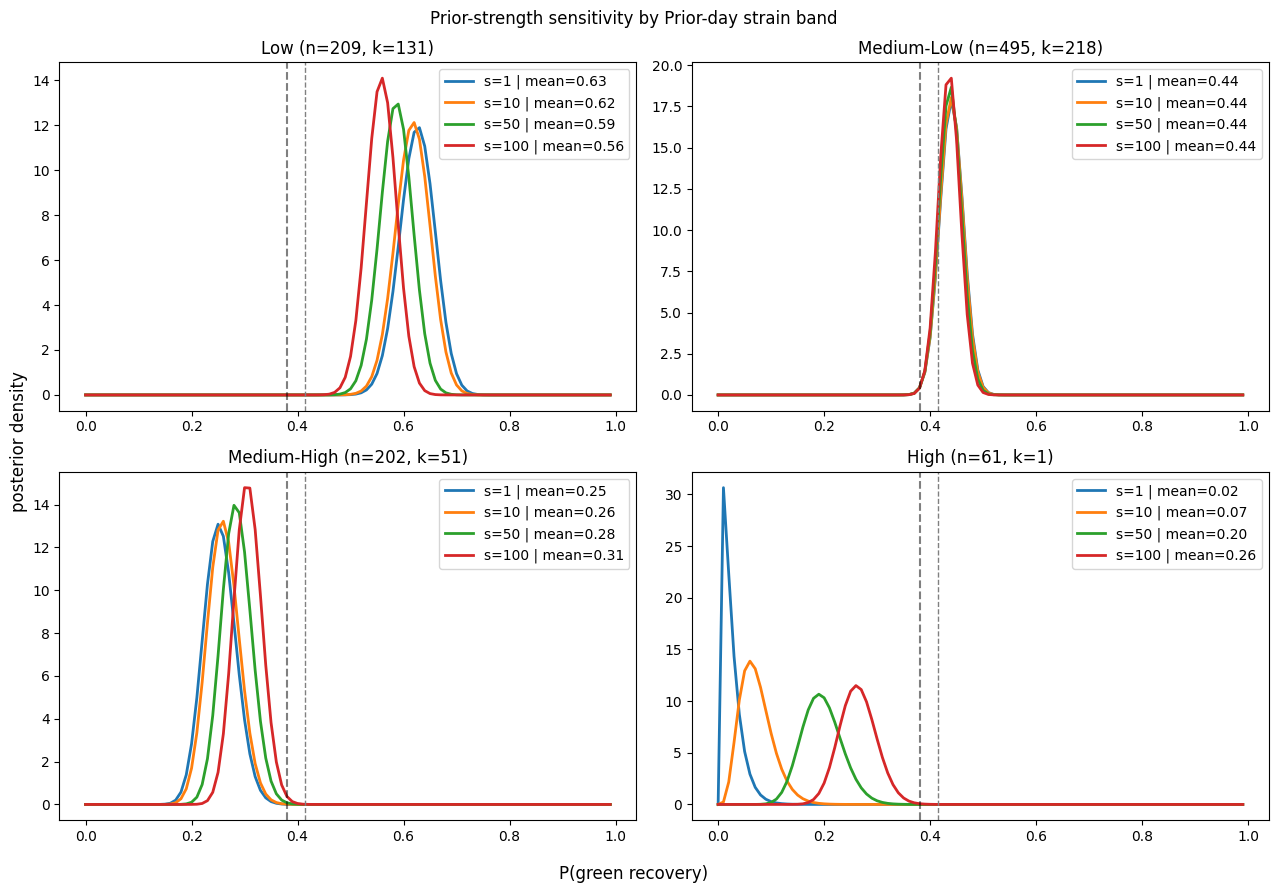

In [12]:
from scipy.stats import beta

x = np.arange(0,1,0.01) # creates an array of 0 to 1 with 0.01 intervals

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
base_rate = green_nights_total / total_nights
strength = [1, 10, 50, 100]
axes = axes.flatten() 
for i, cat in enumerate(strain_cat_dict.keys()):
    ax = axes[i]               # the panel for this band
    n, k = strain_cat_dict[cat][0], strain_cat_dict[cat][1]
    for s in strength:
        a0, b0 = base_rate * s, (1 - base_rate) * s
        a_post, b_post = a0 + k, b0 + (n-k)
        posterior_mean = a_post / (a_post + b_post)
        y = beta.pdf(x, a_post, b_post)
        ax.plot(x, y, linewidth=2, label=f"s={s} | mean={posterior_mean:.2f}")

    ax.axvline(base_rate, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{cat} (n={n}, k={k})")
    
    ax.legend()
    ax.axvline(0.38, linestyle = 'dashed', color = 'black', alpha = 0.5)


fig.supxlabel("P(green recovery)")
fig.supylabel("posterior density")
fig.suptitle("Prior-strength sensitivity by Prior-day strain band")
fig.tight_layout()
fig.show()


Based on the high band having a small count of nights vs the other bands, the mean becomes very sensitive to larger priors (as can be seen above), so to ensure that the raw data remains the driving factor, the strength of the priors was 10 nights of data at base rate.

The above visual makes it really clear to see how the posterior mean changes very slightly in the bigger bands.

Low: 0.62  [0.55, 0.68]  (n=209, raw=0.63)
Medium-Low: 0.44  [0.40, 0.48]  (n=495, raw=0.44)
Medium-High: 0.26  [0.20, 0.32]  (n=202, raw=0.25)
High: 0.07  [0.02, 0.14]  (n=61, raw=0.02)


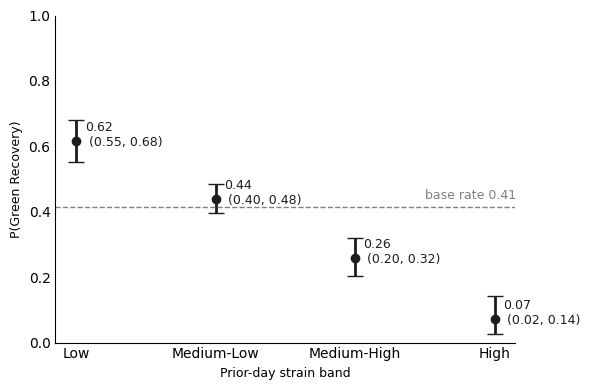

In [13]:

base_rate = green_nights_total / total_nights
s = 10
alpha_prior, beta_prior = base_rate * s, (1 - base_rate) * s


fig, ax = plt.subplots(figsize= [6,4])

for i, cat in enumerate(strain_cat_dict.keys()):
    n, k = strain_cat_dict[cat][0], strain_cat_dict[cat][1]
    a_post, b_post = alpha_prior + k, beta_prior + (n - k)
    posterior_mean = a_post / (a_post + b_post)
    low, high = beta.ppf([0.025, 0.975], a_post, b_post)
    print(f"{cat}: {posterior_mean:.2f}  [{low:.2f}, {high:.2f}]  (n={n}, raw={k/n:.2f})")
    ax.errorbar(cat, posterior_mean, [[posterior_mean - low], [high - posterior_mean]], fmt='o', linewidth=2, capsize=6, color="#1C1C1C")
    ax.annotate(f"{posterior_mean:.2f}\n ({low:.2f}, {high:.2f})", (i, posterior_mean), fontsize=9, color="#1C1C1C",textcoords="offset points", xytext=(6,-4))


ax.annotate(f"base rate {base_rate:.2f}", (2.5, base_rate), textcoords="offset points", xytext=(0, 6), fontsize=9, color='gray')
ax.set_xlabel("Prior-day strain band", fontsize=9)
ax.set_ylabel("P(Green Recovery)", fontsize=9)
ax.set_ylim(0, 1)
# fig.patch.set_facecolor('#f5f3ef')
# ax.set_facecolor('#f5f3ef')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.axhline(base_rate, linestyle='--', color='grey', linewidth=1)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

The 95% credbile intervals above show the values between which there is a 95% probability of the true P(Green Recovery | Strain) being between these values under a weakly informative base rate prior. The intervals do not overlap and provide confidence in the findings that the p(green recovery) falls monotonically as the prior day strain band increases